# Generate distribution plots of the features used in the contamination detector to identify contaminated single cells

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    geom_density,
    ggplot,
    labs,
    scale_fill_gradientn,
    scale_fill_manual,
    theme,
    theme_bw,
    ylim,
)
from plotnine.options import set_option

from cosmicqc import find_outliers

In [2]:
# Directory with data
data_dir = Path(
    "/media/18tbdrive/1.Github_Repositories/nf1_schwann_cell_painting_data/3.processing_features/data/converted_data"
)

# Directory to save cleaned data
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

In [3]:
# Load in converted plate data
plate_df = pd.read_parquet(f"{data_dir}/Plate_3.parquet")

print(plate_df.shape)
plate_df.head()

(18038, 2321)


,Metadata_ImageNumber,Image_Metadata_Plate,Metadata_number_of_singlecells,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_CY5,...,Nuclei_Texture_Variance_DAPI_3_02_256,Nuclei_Texture_Variance_DAPI_3_03_256,Nuclei_Texture_Variance_GFP_3_00_256,Nuclei_Texture_Variance_GFP_3_01_256,Nuclei_Texture_Variance_GFP_3_02_256,Nuclei_Texture_Variance_GFP_3_03_256,Nuclei_Texture_Variance_RFP_3_00_256,Nuclei_Texture_Variance_RFP_3_01_256,Nuclei_Texture_Variance_RFP_3_02_256,Nuclei_Texture_Variance_RFP_3_03_256
0,2,Plate_3,84,11,B10,1,1,2,2,B10_01_3_11_CY5_001_illumcorrect.tiff,...,3103.378595,2928.440215,1289.387179,1113.191261,1143.798104,1229.706291,1860.427125,1792.018063,1751.963638,1860.317249
1,5,Plate_3,84,14,B10,1,1,2,2,B10_01_3_14_CY5_001_illumcorrect.tiff,...,674.346209,687.648994,38.764372,40.170070,40.270733,37.789788,101.849116,99.378570,99.875012,98.784846
2,12,Plate_3,84,20,B10,1,1,2,2,B10_01_3_20_CY5_001_illumcorrect.tiff,...,1566.205750,1486.305372,279.656989,270.323458,300.199086,289.428542,189.134603,192.120194,188.116851,187.663065
3,13,Plate_3,84,21,B10,1,1,2,2,B10_01_3_21_CY5_001_illumcorrect.tiff,...,544.841379,546.635939,35.728497,37.452466,34.925836,34.609601,84.199793,86.931665,85.634432,82.349088
4,14,Plate_3,84,22,B10,1,1,2,2,B10_01_3_22_CY5_001_illumcorrect.tiff,...,1001.824339,979.699936,85.783028,82.215142,84.944425,100.984105,226.980762,230.125834,230.609025,226.963522


Number of outliers: 3028 (16.79%)
Outliers Range:
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Min: -0.3386040270682621
Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256 Max: 0.0
(3028, 5)


,Image_FileName_DAPI,Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256,Image_Metadata_Well,Image_Metadata_Site,Image_Metadata_Plate
4380,,-0.338604,B7,11,Plate_3
17338,,-0.338593,B8,2,Plate_3
7089,,-0.338575,E8,20,Plate_3
383,,-0.338561,G8,23,Plate_3
15190,,-0.338556,B8,19,Plate_3
13613,,-0.338538,G8,24,Plate_3
2576,,-0.338530,E6,2,Plate_3
3821,,-0.338528,G5,3,Plate_3
17740,,-0.338465,B4,5,Plate_3
14254,,-0.338462,D8,16,Plate_3

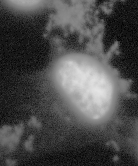
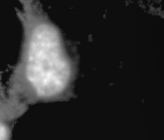
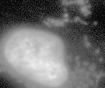
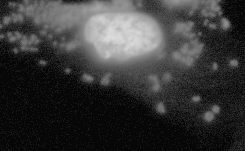
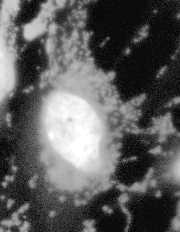
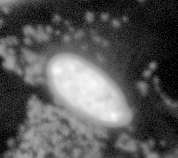
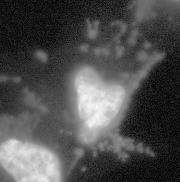
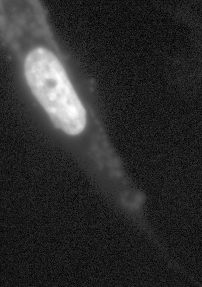
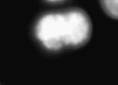
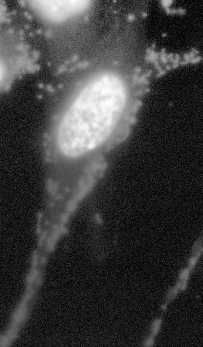

In [4]:
# compartment for bounding boxes
compartment = "Cytoplasm"

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_DAPI",
    "Image_PathName_DAPI",
    f"{compartment}_AreaShape_BoundingBoxMaximum_X",
    f"{compartment}_AreaShape_BoundingBoxMaximum_Y",
    f"{compartment}_AreaShape_BoundingBoxMinimum_X",
    f"{compartment}_AreaShape_BoundingBoxMinimum_Y",
]

# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm texture in nuclei channel
    "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256": 1,
}

irregular_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

irregular_nuclei_outliers_cdf = CytoDataFrame(
    data=irregular_nuclei_outliers,
    display_options={"center_dot": False},
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

print(irregular_nuclei_outliers_cdf.shape)
irregular_nuclei_outliers_cdf.sort_values(
    by="Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256", ascending=True
).head(10)

Number of outliers: 2269 (12.58%)
Outliers Range:
Cytoplasm_Granularity_2_DAPI Min: 1.9138818048921382
Cytoplasm_Granularity_2_DAPI Max: 27.639655282904474
(2269, 5)


,Image_FileName_DAPI,Cytoplasm_Granularity_2_DAPI,Image_Metadata_Well,Image_Metadata_Site,Image_Metadata_Plate
7491,,27.639655,B5,16,Plate_3
1159,,23.187625,D12,6,Plate_3
16479,,20.186922,D12,1,Plate_3
17470,,14.722808,E8,9,Plate_3
10708,,13.983650,F7,4,Plate_3
936,,12.747529,B3,9,Plate_3
10444,,11.313102,C12,16,Plate_3
8635,,10.898749,G6,19,Plate_3
4491,,10.783709,E6,9,Plate_3
2318,,10.739845,D6,11,Plate_3

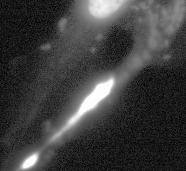
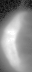
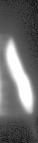
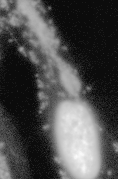
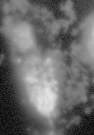
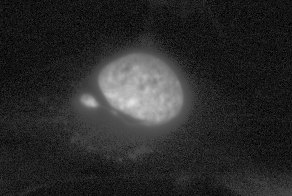
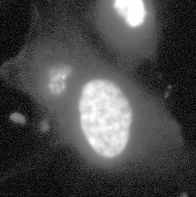
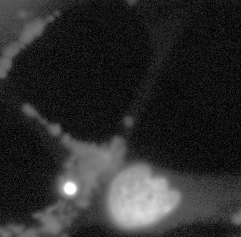
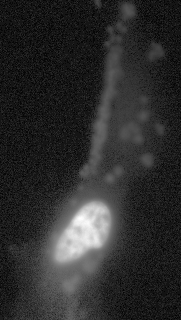
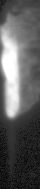
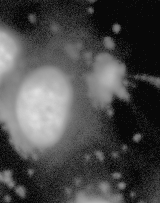
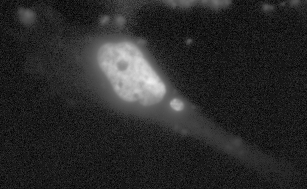
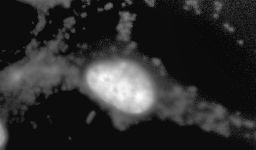
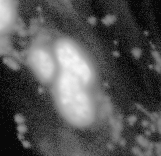
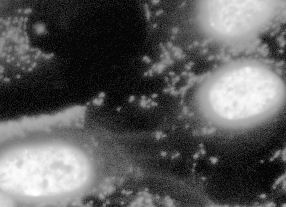

In [5]:
# find irregular shaped nuclei
feature_thresholds = {
    # outlier threshold for only cytoplasm texture in nuclei channel
    "Cytoplasm_Granularity_2_DAPI": 1,
}

extra_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=feature_thresholds,
)

extra_nuclei_outliers_cdf = CytoDataFrame(
    data=extra_nuclei_outliers,
    display_options={"center_dot": False},
)[
    [
        "Image_FileName_DAPI",
        "Cytoplasm_Granularity_2_DAPI",
        "Image_Metadata_Well",
        "Image_Metadata_Site",
        "Image_Metadata_Plate",
    ]
]

print(extra_nuclei_outliers_cdf.shape)
extra_nuclei_outliers_cdf.sort_values(
    by="Cytoplasm_Granularity_2_DAPI", ascending=False
).head(15)

In [6]:
# Add QC_status column to plate_df for irregular nuclei outliers only
plate_df["QC_status"] = "Single-cell passed QC"
plate_df.loc[list(irregular_nuclei_outliers.index), "QC_status"] = (
    "Single-cell failed QC"
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/texture_distribution_plot.png


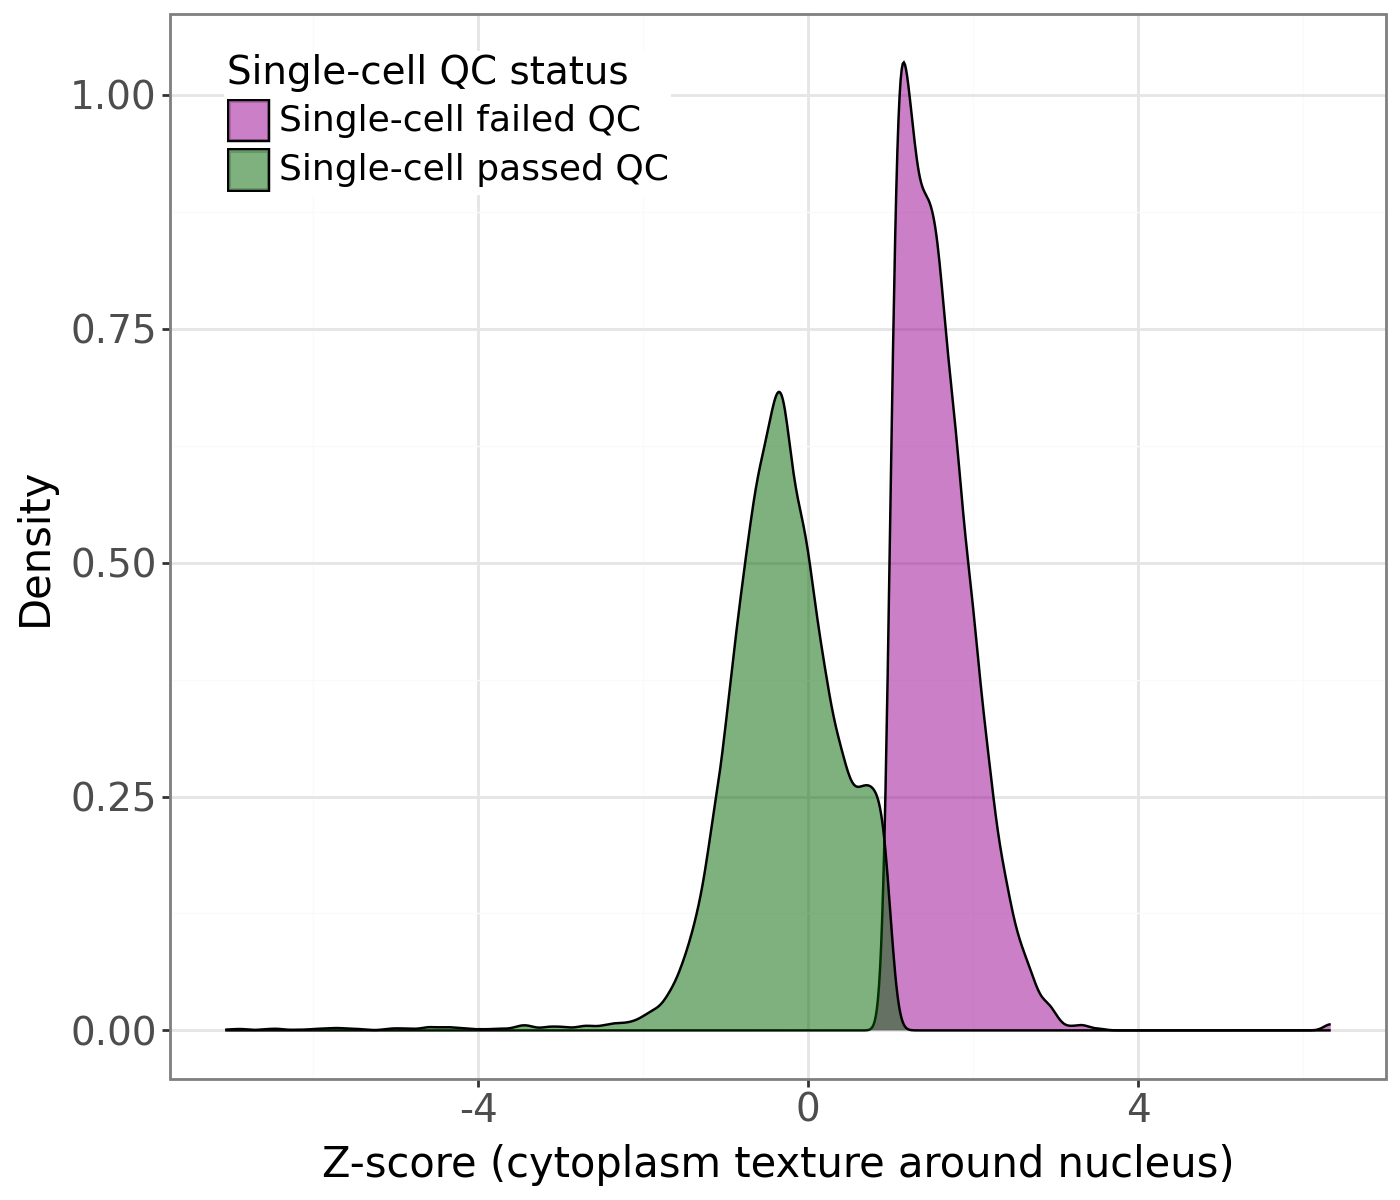

In [7]:
# Z-score normalize the cytoplasm texture for plotting
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
plate_df[["Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256"]] = scaler.fit_transform(
    plate_df[["Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256"]]
)

# Define colors
fill_colors = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Set the figure size
height = 6
width = 7
set_option("figure_size", (width, height))

# Create the density plot
p = (
    ggplot(
        plate_df, aes(x="Cytoplasm_Texture_InfoMeas1_DAPI_3_02_256", fill="QC_status")
    )
    + geom_density(alpha=0.5)
    + scale_fill_manual(values=fill_colors)
    + labs(
        x="Z-score (cytoplasm texture around nucleus)",
        y="Density",
        fill="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.07, 0.96),
        legend_title=element_text(size=14),
        legend_text=element_text(size=13),
        axis_title=element_text(size=15),
        axis_text=element_text(size=14),
    )
)

# Save the plot
p.save(
    figure_dir / "texture_distribution_plot.png",
    dpi=600,
    width=width,
    height=height,
)

# Show plot
p.show()

In [8]:
# Add QC_status column to plate_df for irregular nuclei outliers only
plate_df["QC_status"] = "Single-cell passed QC"
plate_df.loc[list(extra_nuclei_outliers.index), "QC_status"] = "Single-cell failed QC"

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/granularity_distribution_plot.png
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 13149 rows containing non-finite values.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 13149 rows containing non-finite values.


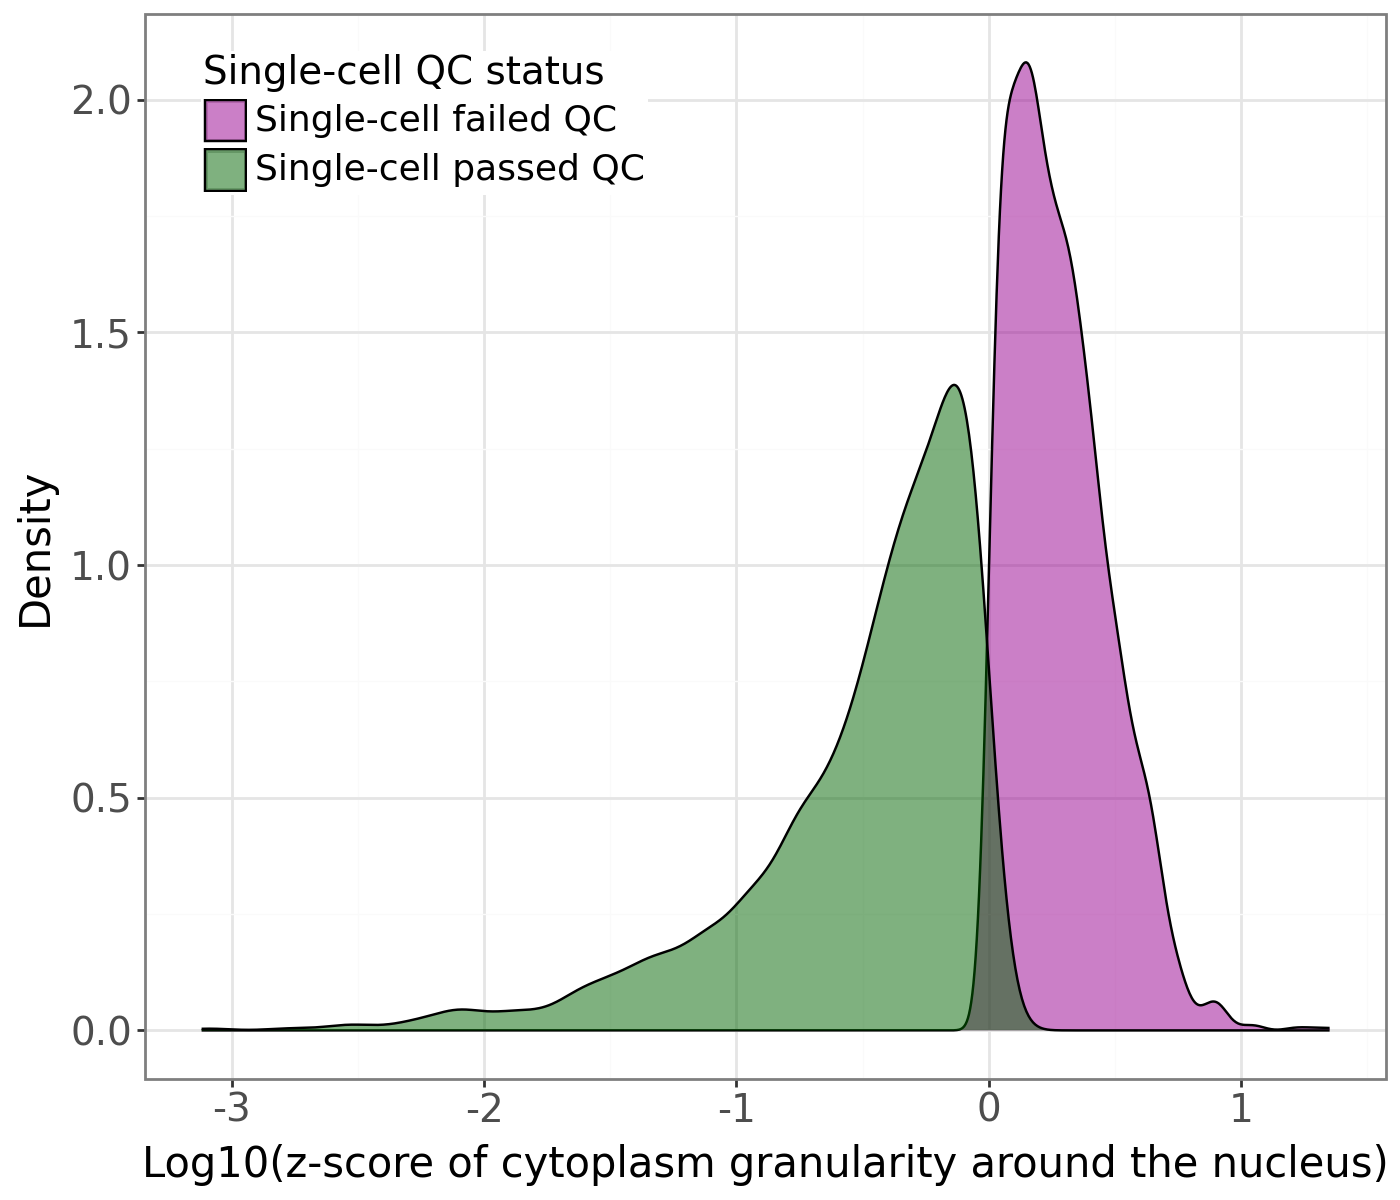

In [9]:
scaler = StandardScaler()
plate_df[["Cytoplasm_Granularity_2_DAPI"]] = scaler.fit_transform(
    plate_df[["Cytoplasm_Granularity_2_DAPI"]]
)

# Take log10 of the cytoplasm granularity
plate_df["Log_Cytoplasm_Granularity"] = np.log10(
    plate_df["Cytoplasm_Granularity_2_DAPI"]
)


# Define colors
fill_colors = {"Single-cell passed QC": "#006400", "Single-cell failed QC": "#990090"}

# Set the figure size
height = 6
width = 7
set_option("figure_size", (width, height))

# Create the density plot
p = (
    ggplot(plate_df, aes(x="Log_Cytoplasm_Granularity", fill="QC_status"))
    + geom_density(alpha=0.5)
    + scale_fill_manual(values=fill_colors)
    + labs(
        x="Log10(z-score of cytoplasm granularity around the nucleus)",
        y="Density",
        fill="Single-cell QC status",
    )
    + theme_bw()
    + theme(
        legend_position=(0.07, 0.96),
        legend_title=element_text(size=14),
        legend_text=element_text(size=13),
        axis_title=element_text(size=15),
        axis_text=element_text(size=14),
    )
)

# Save the plot
p.save(
    figure_dir / "granularity_distribution_plot.png",
    dpi=600,
    width=width,
    height=height,
)

# Show plot
p.show()

In [10]:
# Set QC_status column based on outlier dataframes
plate_df["QC_status"] = "Passed QC"
failed_indices = irregular_nuclei_outliers.index.union(extra_nuclei_outliers.index)
plate_df.loc[failed_indices, "QC_status"] = "Single-cell failed QC"

# Count failed QC cells per well
failed_qc_wells = plate_df.loc[
    plate_df["QC_status"] == "Single-cell failed QC", "Image_Metadata_Well"
]

failed_qc_counts = failed_qc_wells.value_counts().reset_index()
failed_qc_counts.columns = ["Image_Metadata_Well", "Failed_QC_Count"]

# Get total cell count per well
total_cells_per_well = plate_df["Image_Metadata_Well"].value_counts().reset_index()
total_cells_per_well.columns = ["Image_Metadata_Well", "Total_Cell_Count"]

# Merge total cells with failed counts — this keeps all wells
plot_df = total_cells_per_well.merge(
    failed_qc_counts, on="Image_Metadata_Well", how="left"
)
plot_df["Failed_QC_Count"] = plot_df["Failed_QC_Count"].fillna(0)

# Calculate percentage of failed QC cells per well
plot_df["Failed_QC_Proportion"] = (
    plot_df["Failed_QC_Count"] / plot_df["Total_Cell_Count"] * 100
)

# Extract row letter and column number for sorting
plot_df["Row"] = plot_df["Image_Metadata_Well"].str.extract(r"([A-Z])")
plot_df["Column"] = plot_df["Image_Metadata_Well"].str.extract(r"(\d+)").astype(int)

# Sort by column, then row
plot_df = plot_df.sort_values(["Column", "Row"])

# Update well order factor for x-axis to match new order
plot_df["Image_Metadata_Well"] = pd.Categorical(
    plot_df["Image_Metadata_Well"],
    categories=plot_df["Image_Metadata_Well"],
    ordered=True,
)

In [11]:
# Assign genotype based on column number directly
plot_df["Metadata_genotype"] = plot_df["Column"].apply(
    lambda col: (
        "WT"
        if 1 <= col <= 4
        else "HET"
        if 5 <= col <= 8
        else "Null"
        if 9 <= col <= 12
        else "Unknown"
    )
)

print(plot_df.shape)
plot_df.head()

(72, 7)


,Image_Metadata_Well,Total_Cell_Count,Failed_QC_Count,Failed_QC_Proportion,Row,Column,Metadata_genotype
65,B1,43,0.0,0.000000,B,1,WT
58,C1,64,1.0,1.562500,C,1,WT
68,D1,34,0.0,0.000000,D,1,WT
61,E1,51,1.0,1.960784,E,1,WT
67,F1,39,0.0,0.000000,F,1,WT


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/barplot_partial_contamination.png


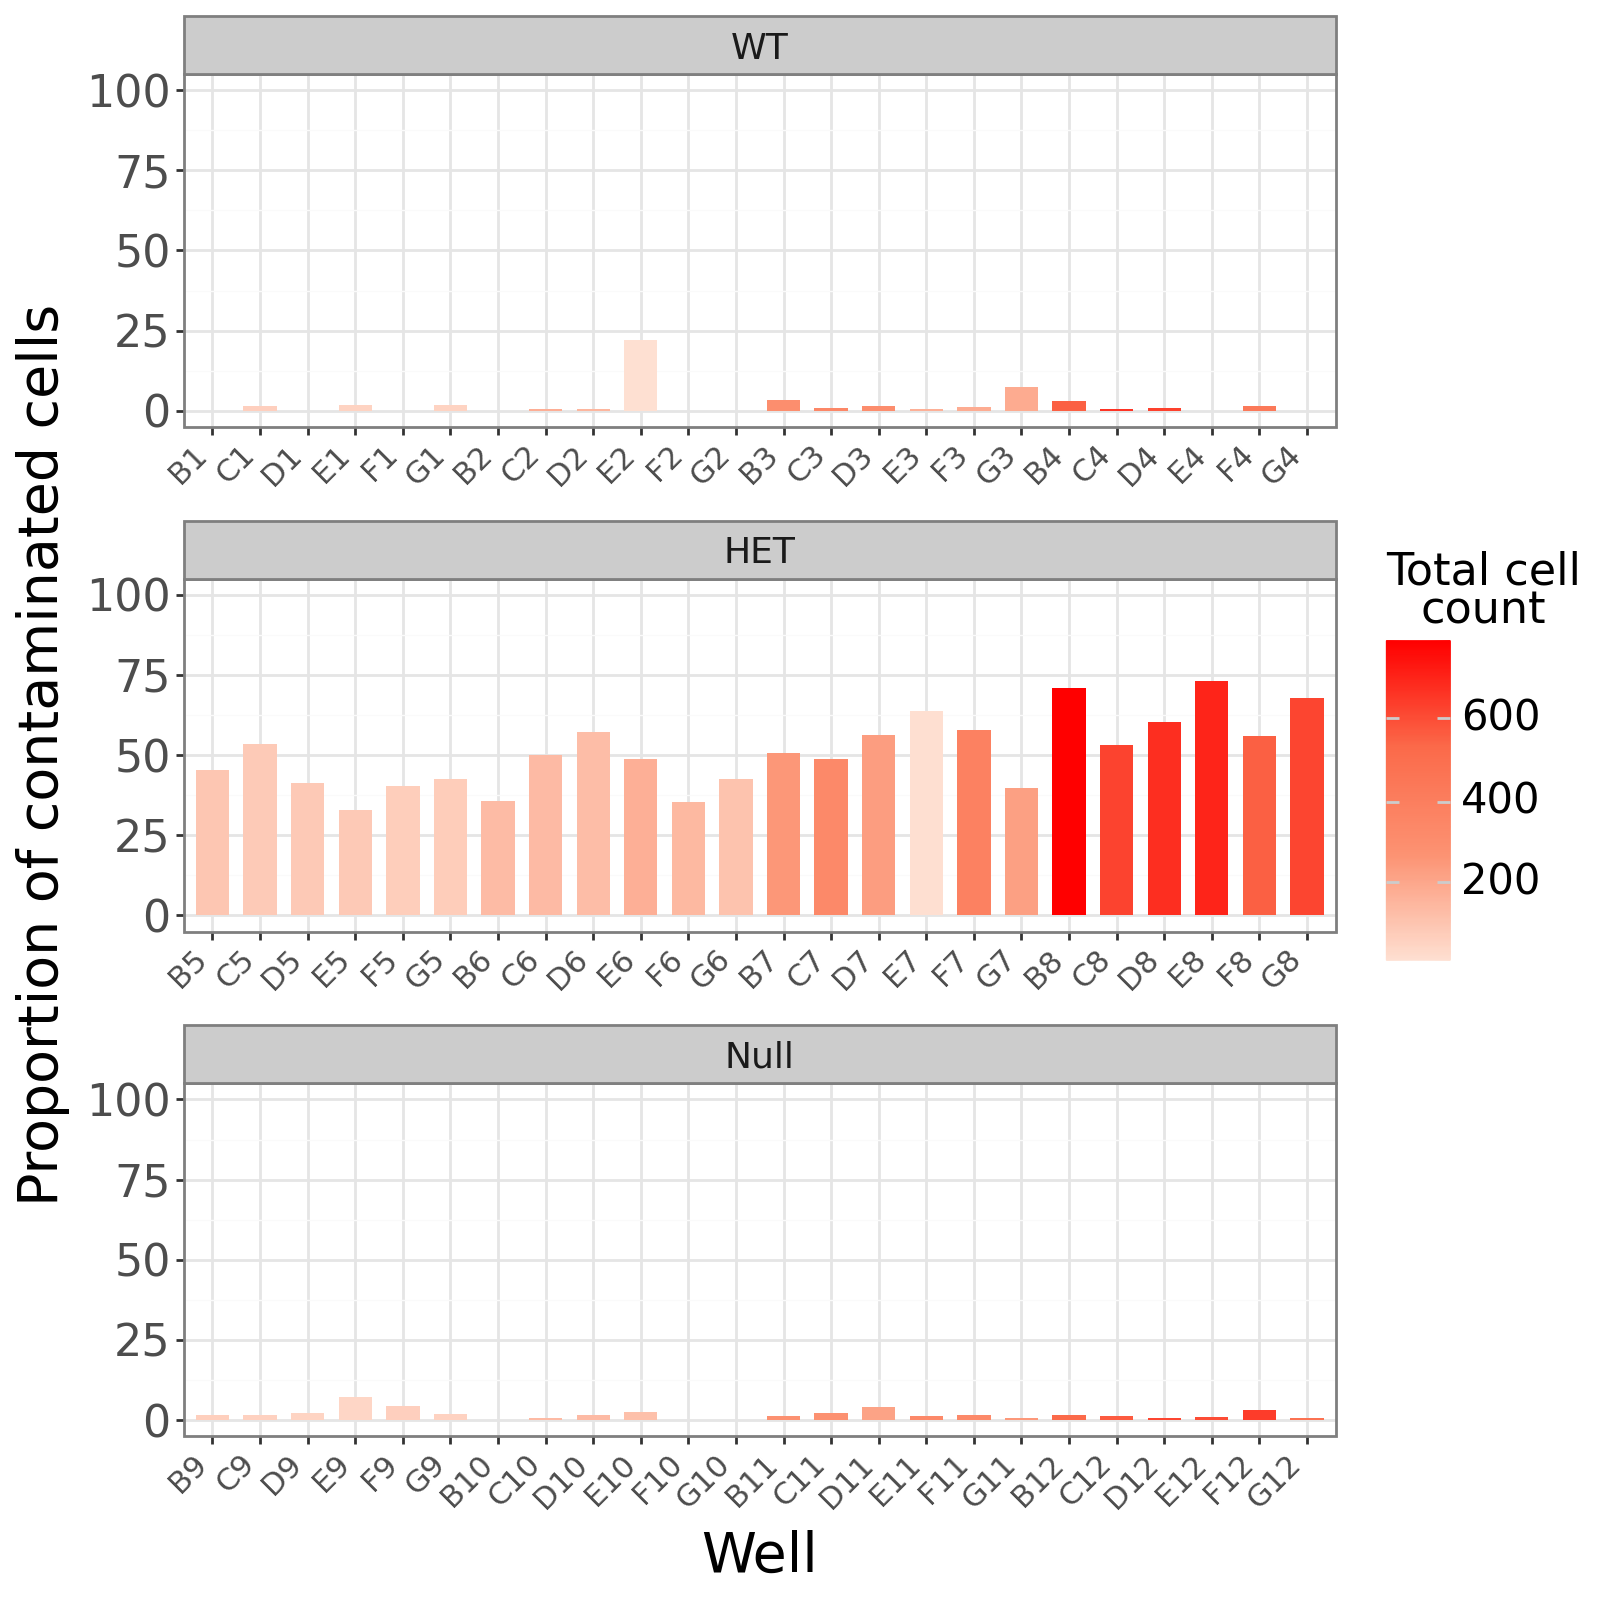

In [12]:
# Set facet order: WT, HET, Null
genotype_order = ["WT", "HET", "Null"]
plot_df["Metadata_genotype"] = pd.Categorical(
    plot_df["Metadata_genotype"], categories=genotype_order, ordered=True
)

# Set the figure size
height = 8
width = 8
set_option("figure_size", (width, height))

# Create bar plot of proportion failed per well
p = (
    ggplot(
        plot_df,
        aes(x="Image_Metadata_Well", y="Failed_QC_Proportion", fill="Total_Cell_Count"),
    )
    + geom_bar(stat="identity", width=0.7)
    + scale_fill_gradientn(colors=["#FEE0D2", "#FC9272", "#FB6A4A", "#FF0000"])
    + labs(x="Well", y="Proportion of contaminated cells", fill="Total cell\ncount")
    + theme_bw()
    + facet_wrap("Metadata_genotype", scales="free_x", ncol=1)
    + ylim(0, 100)
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, size=11),
        axis_text_y=element_text(size=16),
        axis_title=element_text(size=20),
        legend_title=element_text(size=16),
        legend_text=element_text(size=15),
        strip_text=element_text(size=13),  # Increase facet font size
    )
)

# Save the plot
p.save(
    figure_dir / "barplot_partial_contamination.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()